In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
print('All packages loaded')

All packages loaded


# Methodology
For each model I use 90 observations for calibrate, then estimate: 1-day, 1_week, 1_month, 3_month on a rowwing window basis. Meaning, with one model a make four forecasts.

# Import EURIBOR data

In [3]:
df = pd.read_excel('EURIBOR.xlsx')
df.head()

,Date,1 week,1 month,3 month,6 month,12 month
0,2006-04-03,2.614,2.647,2.818,2.992,3.254
1,2006-04-04,2.615,2.649,2.822,3.002,3.264
2,2006-04-05,2.635,2.651,2.824,3.006,3.260
3,2006-04-06,2.653,2.654,2.831,3.007,3.260
4,2006-04-07,2.643,2.641,2.764,2.915,3.159


Let's set the date as index

In [4]:
df.index = df.Date
df = df.iloc[:, 1:] # so we work with percentage data
df.head()

,1 week,1 month,3 month,6 month,12 month
Date,,,,,
2006-04-03,2.614,2.647,2.818,2.992,3.254
2006-04-04,2.615,2.649,2.822,3.002,3.264
2006-04-05,2.635,2.651,2.824,3.006,3.260
2006-04-06,2.653,2.654,2.831,3.007,3.260
2006-04-07,2.643,2.641,2.764,2.915,3.159


<Axes: xlabel='Date'>

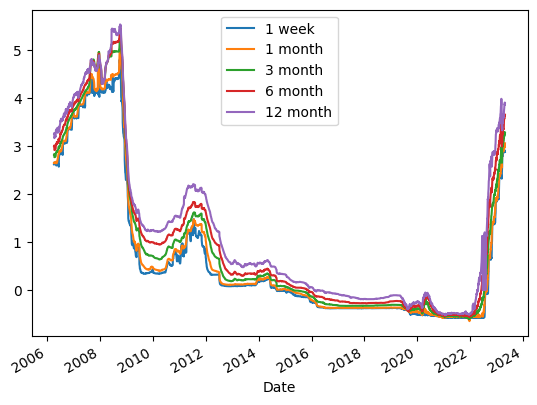

In [5]:
# Visualize data
df.plot()

In [6]:
# Keep the time series of our interest
euribor_ir = df.iloc[:,0]
euribor_ir.head()

Date
2006-04-03    2.614
2006-04-04    2.615
2006-04-05    2.635
2006-04-06    2.653
2006-04-07    2.643
Name: 1 week, dtype: float64

# Random Walk 

Now we are going to compute the estimates starting from 3 months ahead (90 days), compute the RMSE and plot the results

In [7]:
# create data frames where I'll put my predictions
rw_1d = pd.Series(index=euribor_ir.index, dtype=float)
rw_7d = pd.Series(index=euribor_ir.index, dtype=float)
rw_30d = pd.Series(index=euribor_ir.index, dtype=float)
rw_90d = pd.Series(index=euribor_ir.index, dtype=float)

# Store the results in a single df
rw_pred = pd.DataFrame()
rw_pred['1d']=rw_1d
rw_pred['7d']=rw_7d
rw_pred['30d']=rw_30d
rw_pred['90d']=rw_90d

# Fill the Series
i = 0
for step_ahead in (1, 7, 30, 90):
    rw_pred.iloc[:, i] = euribor_ir.shift(step_ahead)
    i += 1

# show results
rw_pred.head()

,1d,7d,30d,90d
Date,,,,
2006-04-03,NaN,NaN,NaN,NaN
2006-04-04,2.614,NaN,NaN,NaN
2006-04-05,2.615,NaN,NaN,NaN
2006-04-06,2.635,NaN,NaN,NaN
2006-04-07,2.653,NaN,NaN,NaN


In [8]:
df1 = pd.merge(euribor_ir, rw_pred, on='Date', how='left')
df1.head()

,1 week,1d,7d,30d,90d
Date,,,,,
2006-04-03,2.614,NaN,NaN,NaN,NaN
2006-04-04,2.615,2.614,NaN,NaN,NaN
2006-04-05,2.635,2.615,NaN,NaN,NaN
2006-04-06,2.653,2.635,NaN,NaN,NaN
2006-04-07,2.643,2.653,NaN,NaN,NaN


In [9]:
# let's remove all the rows with NAs, which will be the 3 months used for calibrating the next models
df1 = df1.dropna()
df1.head()

,1 week,1d,7d,30d,90d
Date,,,,,
2006-08-10,3.092,3.092,2.835,2.855,2.614
2006-08-11,3.091,3.092,2.854,2.846,2.615
2006-08-14,3.091,3.091,2.997,2.840,2.635
2006-08-15,3.091,3.091,3.038,2.832,2.653
2006-08-16,3.092,3.091,3.088,2.823,2.643


<Axes: xlabel='Date'>

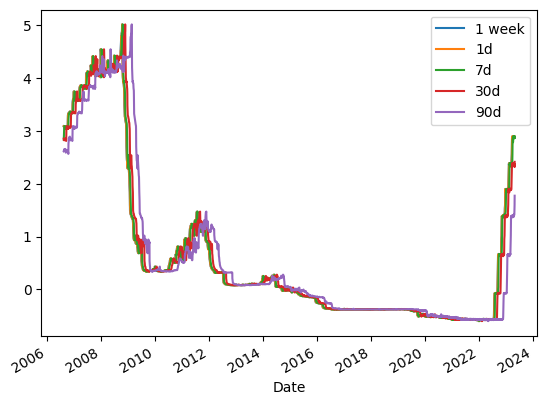

In [10]:
df1.iloc[:, 0:].plot()

THIS DF IS ONLY FOR ILLUSTRATIVE PURPOSES. BUT THE NEXT OBJECTIVE WILL BE TO HAVE A DF FOR EACH TIME FRAME AHEAD ESTIMATES WITH THE DIFFERENT MODELS. NOT A DATAFRAME FOR EACH MODEL AND DIFFERENT TIME FRAME

# Vasicek Model

First step to calibrate the Vasicek model is to create a dataset with 2 columns: one for the the $r_{t+\delta t}$ and another for $r_{t}$.
In our case we have to add another col which is the daily rates shifted by 1

In [11]:
euribor_ir.head()

Date
2006-04-03    2.614
2006-04-04    2.615
2006-04-05    2.635
2006-04-06    2.653
2006-04-07    2.643
Name: 1 week, dtype: float64

In [12]:
df2 = euribor_ir.copy()
df2 = pd.merge(df2, euribor_ir.shift(1), on='Date', how='left')
df2.columns = ['rates t', 'rates t-1']
df2 = df2.dropna()
df2.head()

,rates t,rates t-1
Date,,
2006-04-04,2.615,2.614
2006-04-05,2.635,2.615
2006-04-06,2.653,2.635
2006-04-07,2.643,2.653
2006-04-10,2.630,2.643


The next step is running a regression. Let's start by keeping 90 days and working with that. When it works we generalise by rolling window

In [13]:
prova = df2.iloc[:30, :]

y = prova[['rates t']]
X = prova[['rates t-1']]

model = LinearRegression()
model.fit(X, y)

# Get the estimated parameters
intercept = model.intercept_  # Intercept (bias)
slope = model.coef_[0]        # Slope (coefficients)
dt = 1/252

# Calculate the predicted values (y_hat)
y_hat = model.predict(X)
residuals = y - y_hat

# get the parameter of interest for Vasicek
k = (1-intercept)/dt
theta = slope / (1-intercept)
sigma = np.std(residuals)/dt

################## SIMULATE THE MODEL 
# Initial interest rate
r0 = prova.iloc[-1, 0]

# Number of time steps
n_steps = 90

# Initialize arrays to store interest rate paths
interest_rates = np.zeros(n_steps+1)
interest_rates[0] = r0

# Simulate future interest rate path using Euler's method
for i in range(n_steps):
        dr = k * (theta - interest_rates[i]) * dt + sigma*np.sqrt(dt) * np.random.normal(0,1)
        interest_rates[i+1] = interest_rates[i] + dr

# Time steps
t = np.arange(n_steps+1)

print(f'my theta is {theta} and my initial rate is {r0}')

my theta is [3.04780934] and my initial rate is 2.623


In [36]:
# Let's make a simulation with 90 step ahead, from that we can extract the mean at the time step we want
num_simulations = 100
n_steps = 90

# Initialize an array to store simulated interest rate paths
interest_rate_paths = np.zeros((num_simulations, n_steps+1))
interest_rate_paths[:,0] = r0

# Perform Monte Carlo simulations
for i in range(num_simulations):
    r_t = interest_rate_paths[i, 0]
    for j in range(n_steps):
        dW = np.random.normal() * np.sqrt(dt)
        dr = k * (theta - r_t) * dt + sigma * dW
        r_t += dr
        interest_rate_paths[i, j + 1] = r_t

In [40]:
# let's take our mean estimates
simulated1 = np.mean(interest_rate_paths[:, 1])
simulated7 = np.mean(interest_rate_paths[:, 7])
simulated30 = np.mean(interest_rate_paths[:, 30])
simulated90 = np.mean(interest_rate_paths[:, 90])
print(simulated1, simulated7, simulated30, simulated90)

# let's compute them analitically
analytical1 = r0 * np.exp(-k*dt) + theta * (1 - np.exp(-k*dt))
analytical7 = r0 * np.exp(-k*7*dt) + theta * (1 - np.exp(-k*7*dt))
analytical30 = r0 * np.exp(-k*30*dt) + theta * (1 - np.exp(-k*30*dt))
analytical90 = r0 * np.exp(-k*90*dt) + theta * (1 - np.exp(-k*90*dt))
print(analytical1, analytical7, analytical30, analytical90)

# that's the proof we can use the analytical ones!!!

2.7282307991887493 2.9432431411952558 3.0403924398259385 3.051539123910022
[2.71105426] [2.96424236] [3.04740959] [3.04780934]
